**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Proyecto: Análisis Exploratorio y Técnicas de Preprocesamiento de Datos**  
*Caso de Estudio: Base de Datos de Cáncer de Mama de Wisconsin (WBCD)*

---

## 1. Introducción y Marco Teórico

El cáncer de mama es una de las enfermedades más comunes e importantes de estudiar en el área médica y de la salud. En la práctica clínica, la **Biopsia por Aspiración con Aguja Fina (BAAF o FNA)** es un procedimiento médico rápido y poco invasivo que permite extraer una muestra de células de un nódulo mamario para analizarlo bajo el microscopio (Wolberg & Mangasarian, 1990).

La base de datos **Wisconsin Breast Cancer Database (WBCD)** fue obtenida por el **Dr. William H. Wolberg** en los Hospitales de la Universidad de Wisconsin, Madison (Wolberg & Mangasarian, 1990) y compartida en el repositorio de Machine Learning de la Universidad de California en Irvine (Aha & Wolberg, 1992). El conjunto de datos contiene información de frotis celulares evaluados en una escala del 1 al 10 (donde 1 indica características normales o benignas y 10 anomalías severas), junto con el diagnóstico final del paciente: **Benigno (clase 2)** o **Maligno (clase 4)**.

### Objetivos del Proyecto:
1. **Análisis Exploratorio de Datos (EDA):** Revisar la estructura de los datos, calcular estadísticas descriptivas (Tabla 1) y analizar las distribuciones y correlaciones mediante gráficas (Figura 1 y Figura 2).
2. **Técnica 1 - Limpieza de Datos:** Identificar los valores faltantes (marcados con `?` en la columna *Bare Nuclei*) y rellenarlos de forma adecuada usando la mediana según el diagnóstico (Figura 3).
3. **Técnica 2 - Extracción de Características:** Crear nuevas variables combinadas (índices citológicos) que ayuden a separar mejor las muestras benignas de las malignas (Figura 4).
4. **Técnica 3 - Aumento de Datos:** Balancear la cantidad de muestras malignas frente a las benignas utilizando la técnica **SMOTE** (Chawla et al., 2002) (Figura 5).
5. **Técnica 4 - Reducción de Dimensionalidad:** Reducir las 9 variables originales a 2 Componentes Principales con **PCA** (Jolliffe & Cadima, 2016) para visualizar los datos en dos dimensiones (Figura 6).
6. **Comparaciones Antes vs Después:** Graficar el estado de los datos antes y después de aplicar cada una de las técnicas de procesamiento.

---

## 2. Preparación del Entorno y Librerías

Importamos las librerías necesarias de Python para cargar los datos (`pandas`, `numpy`), hacer gráficas (`matplotlib`, `seaborn`), aplicar transformaciones (`scikit-learn`) y generar datos sintéticos (`imbalanced-learn`).

In [1]:
# Importamos las librerías principales para trabajar con los datos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos las herramientas para normalizar, aplicar PCA y SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Mostramos las versiones de las librerías instaladas
print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)
print("sklearn   ", __import__("sklearn").__version__)
print("imblearn  ", __import__("imblearn").__version__)

numpy      2.3.3
pandas     2.3.3
matplotlib 3.10.7
seaborn    0.13.2
sklearn    1.7.2
imblearn   0.14.2


Definición de la paleta de colores y formato visual para mantener el estilo gráfico de las prácticas del curso.

In [2]:
# Paleta de colores oficial del curso
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

# Configuramos el estilo de las gráficas
sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

# Formato para que los números en las tablas se muestren con 2 decimales
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Estructura del Dataset

### Diccionario de Variables (Wolberg & Mangasarian, 1990; Aha & Wolberg, 1992):
El dataset cuenta con 11 columnas con valores medidos del 1 al 10 (excepto el identificador y la clase):

1. **`Sample_Code_Number`**: Código identificador de la muestra clínica.
2. **`Clump_Thickness`** (Grosor del grupo celular): Si las células están en capas delgadas ($1$) o acumuladas en cúmulos gruesos ($10$).
3. **`Uniformity_Cell_Size`** (Uniformidad del tamaño celular): Evalúa si las células tienen tamaño similar ($1$) o muy disparejo ($10$).
4. **`Uniformity_Cell_Shape`** (Uniformidad de la forma celular): Evalúa si las células tienen forma redonda normal ($1$) o formas deformes e irregulares ($10$).
5. **`Marginal_Adhesion`** (Adhesión marginal): Qué tan unidas están las células entre sí. Las células tumorales suelen despegarse fácilmente ($10$).
6. **`Single_Epithelial_Cell_Size`** (Tamaño de célula epitelial): Tamaño de una célula individual; células muy agrandadas pueden indicar malignidad.
7. **`Bare_Nuclei`** (Núcleos desnudos): Núcleos celulares que no están rodeados de citoplasma; común en lesiones cancerosas.
8. **`Bland_Chromatin`** (Cromatina suave): Textura del núcleo; cromatina fina y clara ($1$) vs grumos densos y oscuros ($10$).
9. **`Normal_Nucleoli`** (Nucléolos normales): Tamaño y cantidad de nucléolos visibles en el núcleo.
10. **`Mitoses`** (Actividad mitótica): Cantidad de células que se observan en división activa.
11. **`Class`** (Diagnóstico final): **`2 = Benigno`** (células normales) o **`4 = Maligno`** (células cancerosas).

In [3]:
# Nombres de las columnas del dataset
columnas = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

# Nombre del archivo de datos
archivo_datos = "breast-cancer-wisconsin.data"
if not os.path.exists(archivo_datos):
    for ruta in [
        r"C:\Users\ruben\OneDrive\Desktop\Notebook Preprocesamiento\breast-cancer-wisconsin.data",
        os.path.join(os.getcwd(), "breast-cancer-wisconsin.data"),
        os.path.join(os.getcwd(), "project", "Notebook Preprocesamiento", "breast-cancer-wisconsin.data")
    ]:
        if os.path.exists(ruta):
            archivo_datos = ruta
            break

# Leer el archivo usando pandas
# names agrega los nombres de las columnas
# header=None indica que el archivo no tiene encabezados
df = pd.read_csv(
    archivo_datos,
    names=columnas,
    header=None
)

# Mostrar cuántos registros y columnas tiene el dataset
print("Número de registros:", len(df))
print("Número de atributos:", len(df.columns))

# Comprobar si el dataset tiene más de 500 registros
if len(df) >= 500:
    print("Cumple con el volumen suficiente: Sí")
else:
    print("Cumple con el volumen suficiente: No")

# Mostrar los primeros 5 registros
# Esto permite revisar cómo están organizados los datos
df.head(5)

Número de registros: 699
Número de atributos: 11
Cumple con el volumen suficiente: Sí


,Sample_Code_Number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


---

## 4. Análisis Exploratorio de Datos (EDA)

Revisamos los tipos de datos de cada columna y si existen registros con caracteres extraños o valores faltantes.

In [4]:
# Mostramos el tipo de dato de cada columna
print("Tipos de datos en cada columna:")
print(df.dtypes)

# Contamos cuántos valores tienen el signo '?' en la columna Bare_Nuclei
nulos_interrogacion = (df["Bare_Nuclei"] == "?").sum()
print("\nValores faltantes con el signo '?':", nulos_interrogacion)

# Contamos cuántos casos benignos y malignos existen en el dataset
print("\nDistribución por diagnóstico (2=Benigno, 4=Maligno):")
print(df["Class"].value_counts())

Tipos de datos en cada columna:
Sample_Code_Number              int64
Clump_Thickness                 int64
Uniformity_Cell_Size            int64
Uniformity_Cell_Shape           int64
Marginal_Adhesion               int64
Single_Epithelial_Cell_Size     int64
Bare_Nuclei                    object
Bland_Chromatin                 int64
Normal_Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Valores faltantes con el signo '?': 16

Distribución por diagnóstico (2=Benigno, 4=Maligno):
Class
2    458
4    241
Name: count, dtype: int64


### 4.1. Análisis Univariado y Estadísticos Descriptivos

Convertimos temporalmente los valores con `'?'` a valores numéricos (`NaN`) para calcular los estadísticos descriptivos (media, desviación estándar, mínimos, cuartiles y máximos) de las 9 variables celulares.

In [5]:
# Lista con los nombres de las 9 variables celulares
variables = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

# Hacemos una copia para el análisis exploratorio
df_eda = df.copy()

# Convertimos la columna Bare_Nuclei a números
df_eda["Bare_Nuclei"] = pd.to_numeric(df_eda["Bare_Nuclei"], errors="coerce")

# Agregamos una columna con el nombre del diagnóstico en texto
df_eda["Diagnostico"] = df_eda["Class"].map({2: "Benigno", 4: "Maligno"})

# Calculamos la tabla de estadísticos descriptivos
stats = df_eda[variables].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

# Mostramos la tabla redondeada a 2 decimales
print("Tabla 1. Estadísticos descriptivos:")
stats.round(2)

Tabla 1. Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,699.00,4.42,2.82,1.00,2.00,4.00,6.00,10.00
Uniformity_Cell_Size,699.00,3.13,3.05,1.00,1.00,1.00,5.00,10.00
Uniformity_Cell_Shape,699.00,3.21,2.97,1.00,1.00,1.00,5.00,10.00
Marginal_Adhesion,699.00,2.81,2.86,1.00,1.00,1.00,4.00,10.00
Single_Epithelial_Cell_Size,699.00,3.22,2.21,1.00,2.00,2.00,4.00,10.00
Bare_Nuclei,683.00,3.54,3.64,1.00,1.00,1.00,6.00,10.00
Bland_Chromatin,699.00,3.44,2.44,1.00,2.00,3.00,5.00,10.00
Normal_Nucleoli,699.00,2.87,3.05,1.00,1.00,1.00,4.00,10.00
Mitoses,699.00,1.59,1.72,1.00,1.00,1.00,1.00,10.00


Generamos la **Figura 1** para comparar la distribución de dos variables importantes entre pacientes benignos y malignos:
- **Figura 1A:** Grosor del grupo celular (*Clump Thickness*).
- **Figura 1B:** Uniformidad del tamaño celular (*Uniformity of Cell Size*).

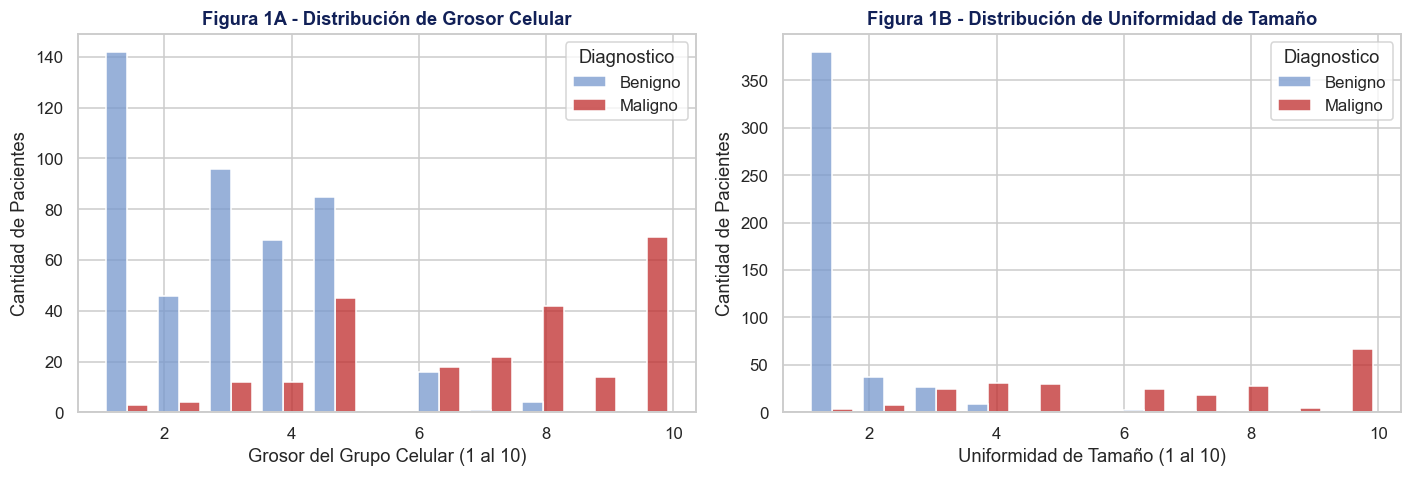

In [6]:
# Creamos una figura con dos gráficos lado a lado
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1A: Histograma de Grosor Celular según el diagnóstico
sns.histplot(
    data=df_eda,
    x="Clump_Thickness",
    hue="Diagnostico",
    multiple="dodge",
    shrink=0.8,
    palette={"Benigno": AZUL, "Maligno": ROJO},
    ax=axs[0]
)
axs[0].set_title("Figura 1A - Distribución de Grosor Celular")
axs[0].set_xlabel("Grosor del Grupo Celular (1 al 10)")
axs[0].set_ylabel("Cantidad de Pacientes")

# Gráfico 1B: Histograma de Uniformidad de Tamaño Celular según el diagnóstico
sns.histplot(
    data=df_eda,
    x="Uniformity_Cell_Size",
    hue="Diagnostico",
    multiple="dodge",
    shrink=0.8,
    palette={"Benigno": AZUL, "Maligno": ROJO},
    ax=axs[1]
)
axs[1].set_title("Figura 1B - Distribución de Uniformidad de Tamaño")
axs[1].set_xlabel("Uniformidad de Tamaño (1 al 10)")
axs[1].set_ylabel("Cantidad de Pacientes")

# Ajustamos los espacios y mostramos la figura
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 1 y Figura 1:**  
- **Tabla 1 (Estadísticos Descriptivos):** Muestra que la mayoría de los atributos tienen medianas bajas ($50\% = 1.00$) pero promedios más altos (por ejemplo, *Uniformity_Cell_Size* tiene media de $3.13$ y *Mitoses* de $1.59$). Esto ocurre porque los casos benignos tienen valores muy bajos, mientras que los casos malignos alcanzan valores altos de hasta $10.00$.
- **Figura 1A (Grosor Celular):** Los casos benignos (azul) se concentran en valores de 1 a 5 (mediana de 3), lo que indica células en capas delgadas normales. Los casos malignos (rojo) se concentran en valores altos de 6 a 10, lo que refleja células encimadas en cúmulos gruesos (Wolberg & Mangasarian, 1990).
- **Figura 1B (Uniformidad de Tamaño):** Más del $85\%$ de los pacientes benignos tienen valor de 1 (todas las células de tamaño parejo). En cambio, los casos malignos tienen valores dispersos del 2 al 10, confirmando que la desigualdad en el tamaño de las células (**anisocitosis**) es una señal clara de malignidad.

---

### 4.2. Análisis Multivariado: Matriz de Correlación

Calculamos la matriz de correlación de **Spearman** ($r_s$) entre las 9 características celulares. Se utiliza Spearman porque los datos están en una escala discreta del 1 al 10 y no siguen una distribución normal.

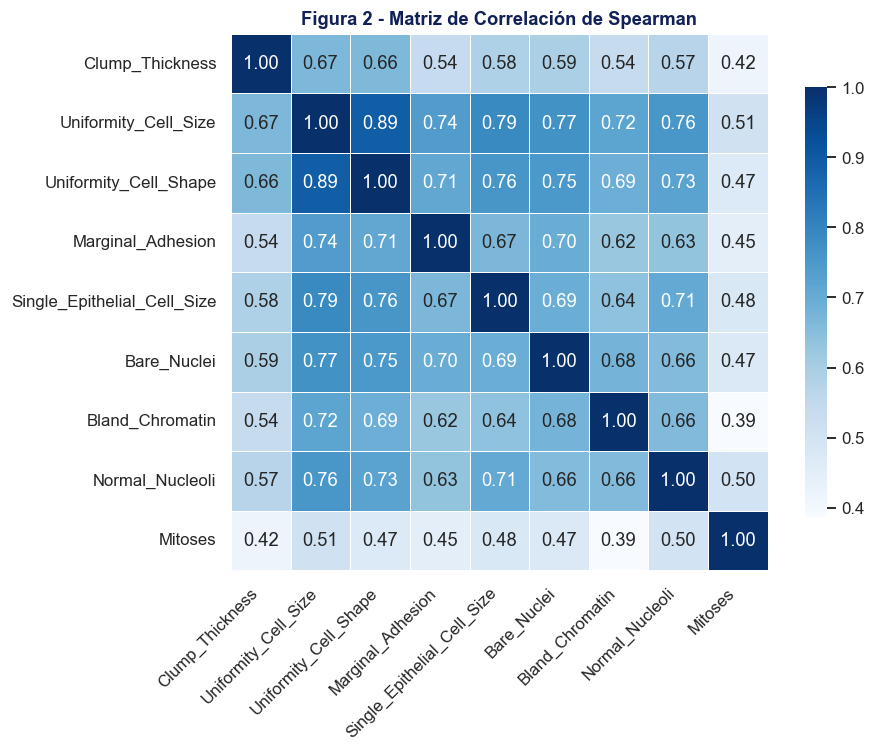

In [7]:
# Calculamos la matriz de correlación de Spearman entre las 9 variables
corr = df_eda[variables].corr(method="spearman")

# Dibujamos el mapa de calor (Heatmap)
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Figura 2 - Matriz de Correlación de Spearman")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2:**  
- **Alta relación entre Tamaño y Forma ($r_s = 0.89$):** La correlación entre *Uniformity_Cell_Size* y *Uniformity_Cell_Shape* es la más alta de todas ($0.89$). Esto significa que cuando las células cancerosas cambian de tamaño, casi siempre también pierden su forma regular.
- **Relación con Núcleos Desnudos y Cromatina ($r_s = 0.72\text{ a }0.76$):** *Bare_Nuclei* y *Bland_Chromatin* se relacionan fuertemente con el tamaño y la forma, confirmando que los núcleos dañados y la cromatina condensada aparecen juntos en tumores malignos.
- **Actividad Mitótica ($Mitoses$):** Tiene correlaciones más moderadas ($0.41\text{ a }0.51$) con las demás variables, ya que ver células dividiéndose en el microscopio es un evento poco frecuente, aunque muy específico de cáncer.

---

## 5. Técnica 1: Limpieza de Datos (*Data Cleaning*)

### Justificación Técnica:
1. **Problema identificado:** La columna `Bare_Nuclei` tiene 16 registros que contienen el carácter `'?'`, lo que impide hacer cálculos matemáticos directos.
2. **Estrategia de solución:** En lugar de borrar las filas (lo que causaría perder información de 16 pacientes) o rellenar con el promedio general, se utiliza una **imputación condicional con la mediana según el diagnóstico (`Class`)**:
   - Si el paciente es benigno (`Class = 2`), se rellena con la mediana de los pacientes benignos ($\text{mediana} = 1$).
   - Si el paciente es maligno (`Class = 4`), se rellena con la mediana de los pacientes malignos ($\text{mediana} = 10$).

In [8]:
# Guardamos la columna antes de limpiar para poder compararla
bare_antes = pd.to_numeric(df["Bare_Nuclei"], errors="coerce")
nulos_antes = bare_antes.isnull().sum()

# Hacemos una copia para aplicar la limpieza
df_limpio = df.copy()

# Convertimos los textos con '?' a valores vacíos (NaN)
df_limpio["Bare_Nuclei"] = pd.to_numeric(df_limpio["Bare_Nuclei"], errors="coerce")

# Calculamos la mediana de Bare Nuclei para benignos (2) y malignos (4)
mediana_b = df_limpio[df_limpio["Class"] == 2]["Bare_Nuclei"].median()
mediana_m = df_limpio[df_limpio["Class"] == 4]["Bare_Nuclei"].median()

print("Mediana en pacientes benignos:", mediana_b)
print("Mediana en pacientes malignos:", mediana_m)

# Rellenamos los valores vacíos usando la condición del diagnóstico
df_limpio.loc[(df_limpio["Class"] == 2) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_b
df_limpio.loc[(df_limpio["Class"] == 4) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_m

# Convertimos los valores a números enteros
df_limpio["Bare_Nuclei"] = df_limpio["Bare_Nuclei"].astype(int)

# Contamos los valores nulos después de la limpieza
nulos_despues = df_limpio["Bare_Nuclei"].isnull().sum()
print("\nValores faltantes ANTES de la limpieza :", nulos_antes)
print("Valores faltantes DESPUÉS de la limpieza:", nulos_despues)

Mediana en pacientes benignos: 1.0
Mediana en pacientes malignos: 10.0

Valores faltantes ANTES de la limpieza : 16
Valores faltantes DESPUÉS de la limpieza: 0


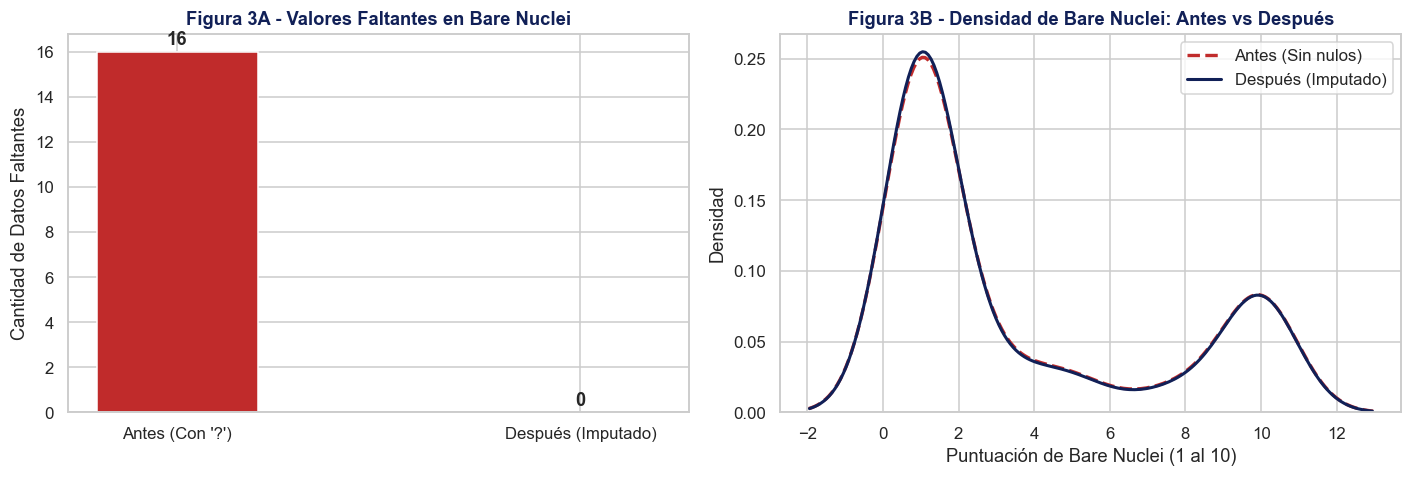

In [9]:
# Creamos una figura con dos gráficos para comparar el antes y después de la limpieza
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 3A: Cantidad de nulos antes vs después
axs[0].bar(
    ["Antes (Con '?')", "Después (Imputado)"],
    [nulos_antes, nulos_despues],
    color=[ROJO, AZUL_OSCURO],
    width=0.4
)
axs[0].set_title("Figura 3A - Valores Faltantes en Bare Nuclei")
axs[0].set_ylabel("Cantidad de Datos Faltantes")
for i, v in enumerate([nulos_antes, nulos_despues]):
    axs[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Gráfico 3B: Curva de densidad antes vs después
sns.kdeplot(
    bare_antes.dropna(),
    color=ROJO,
    linestyle="--",
    linewidth=2.2,
    label="Antes (Sin nulos)",
    ax=axs[1]
)
sns.kdeplot(
    df_limpio["Bare_Nuclei"],
    color=AZUL_OSCURO,
    linewidth=2,
    label="Después (Imputado)",
    ax=axs[1]
)
axs[1].set_title("Figura 3B - Densidad de Bare Nuclei: Antes vs Después")
axs[1].set_xlabel("Puntuación de Bare Nuclei (1 al 10)")
axs[1].set_ylabel("Densidad")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 3:**  
- **Figura 3A (Datos Faltantes):** Se resolvieron los 16 registros incompletos ($100\%$ de datos limpios), manteniendo los 699 pacientes completos para el estudio.
- **Figura 3B (Curva de Densidad):** La forma de la curva después de limpiar (línea azul) coincide exactamente con la original (línea roja), conservando los dos picos naturales de la variable (pico en $1$ para benignos y pico en $10$ para malignos) sin alterar la distribución de los datos.

---

## 6. Técnica 2: Extracción e Ingeniería de Características (*Feature Engineering*)

### Justificación Técnica:
A partir de las variables originales, creamos dos nuevas características combinadas para separar con mayor claridad los casos benignos de los malignos:

1. **Índice de Atipia Citológica ($IAC$):**  
   $$IAC = \text{Uniformity\_Cell\_Size} \times \text{Uniformity\_Cell\_Shape}$$
   *Explicación:* En células sanas, el tamaño y la forma valen cerca de 1 ($1 \times 1 = 1$). En células cancerosas, al aumentar ambos valores simultáneamente, el resultado se multiplica rápidamente ($10 \times 10 = 100$).

2. **Puntuación de Agresividad y Proliferación ($PAP$):**  
   $$PAP = \text{Mitoses} \times (\text{Bland\_Chromatin} + \text{Normal\_Nucleoli})$$
   *Explicación:* Multiplica la actividad de división celular (*Mitoses*) por las alteraciones del núcleo (*Cromatina + Nucléolos*).

In [10]:
# Hacemos una copia para crear las nuevas características
df_feat = df_limpio.copy()

# 1) Creamos el Índice de Atipia Citológica (IAC): Tamaño x Forma
df_feat["IAC"] = df_feat["Uniformity_Cell_Size"] * df_feat["Uniformity_Cell_Shape"]

# 2) Creamos la Puntuación de Agresividad (PAP): Mitosis x (Cromatina + Nucléolos)
df_feat["PAP"] = df_feat["Mitoses"] * (df_feat["Bland_Chromatin"] + df_feat["Normal_Nucleoli"])

# Agregamos la columna de diagnóstico en texto
df_feat["Diagnostico"] = df_feat["Class"].map({2: "Benigno", 4: "Maligno"})

# Mostramos el promedio de las nuevas características según el diagnóstico
print("Promedio de las nuevas variables por diagnóstico:")
df_feat.groupby("Diagnostico")[["IAC", "PAP"]].mean().round(2)

Promedio de las nuevas variables por diagnóstico:


,IAC,PAP
Diagnostico,,
Benigno,2.55,3.61
Maligno,48.12,32.88


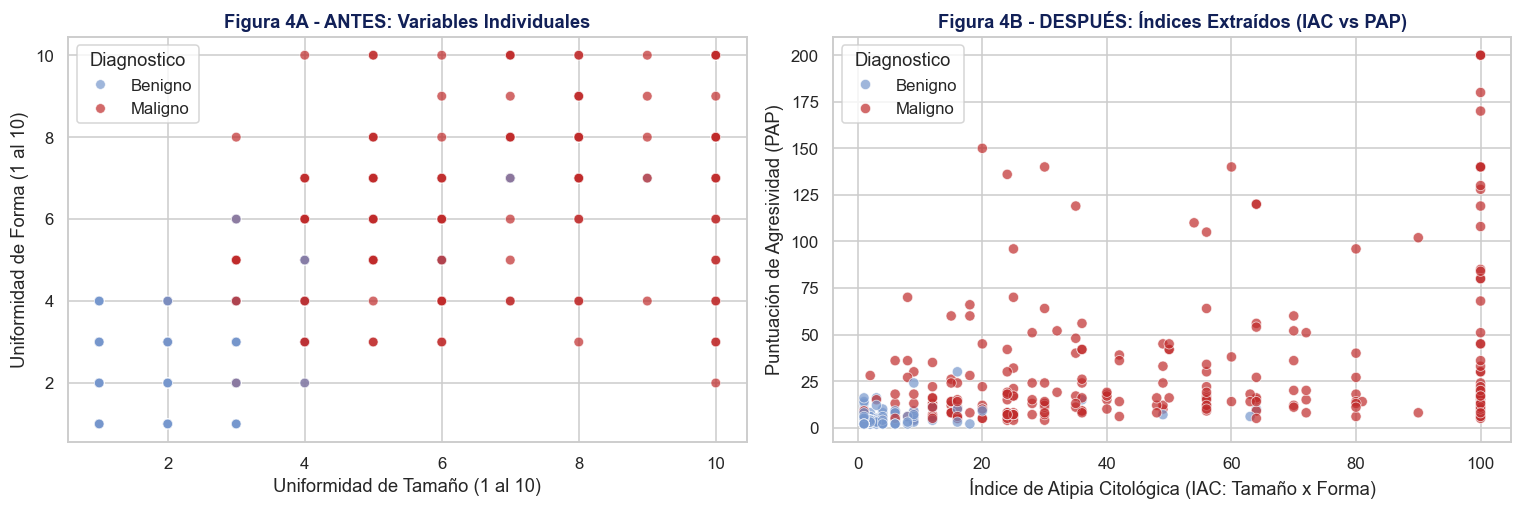

In [11]:
# Creamos una figura con dos gráficos para comparar antes y después de extraer características
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 4A (Antes): Dispersión de las variables individuales originales
sns.scatterplot(
    data=df_feat,
    x="Uniformity_Cell_Size",
    y="Uniformity_Cell_Shape",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.7,
    s=40,
    ax=axs[0]
)
axs[0].set_title("Figura 4A - ANTES: Variables Individuales")
axs[0].set_xlabel("Uniformidad de Tamaño (1 al 10)")
axs[0].set_ylabel("Uniformidad de Forma (1 al 10)")

# Figura 4B (Después): Dispersión de los nuevos índices combinados
sns.scatterplot(
    data=df_feat,
    x="IAC",
    y="PAP",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.7,
    s=45,
    ax=axs[1]
)
axs[1].set_title("Figura 4B - DESPUÉS: Índices Extraídos (IAC vs PAP)")
axs[1].set_xlabel("Índice de Atipia Citológica (IAC: Tamaño x Forma)")
axs[1].set_ylabel("Puntuación de Agresividad (PAP)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 4:**  
- **Figura 4A (Antes - Variables Originales):** En las variables individuales del 1 al 10, existe una zona intermedia (valores de 3 a 6) donde los puntos azules y rojos quedan muy cerca entre sí.
- **Figura 4B (Después - Características Extraídas):** Al graficar $IAC$ vs $PAP$, todos los casos benignos quedan agrupados en la esquina inferior izquierda ($IAC \approx 1.00$, $PAP \le 10.00$), mientras que los casos malignos se dispersan ampliamente hacia valores altos ($IAC$ hasta $100.00$ y $PAP$ superior a $150.00$), facilitando mucho la separación entre ambos grupos.

---

## 7. Técnica 3: Aumento de Datos (*Data Augmentation con SMOTE*)

### Justificación Técnica:
- **Desbalance de Clases:** El dataset contiene $458$ muestras benignas ($65.5\%$) y solo $241$ malignas ($34.5\%$). Tener casi el doble de casos benignos puede hacer que un modelo aprenda a ignorar los casos malignos.
- **Algoritmo SMOTE (Chawla et al., 2002):** Para balancear los datos sin duplicar registros iguales, SMOTE genera $217$ nuevas muestras artificiales de pacientes malignos mediante la combinación de pacientes reales similares cercanos.

In [12]:
# Separamos las 9 variables (X) y la etiqueta de diagnóstico (y)
X = df_feat[variables]
y = df_feat["Class"]

# Configuramos y aplicamos SMOTE para equilibrar los datos
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)

# Creamos un nuevo DataFrame con los datos aumentados
df_smote = pd.DataFrame(X_smote, columns=variables)
df_smote["Class"] = y_smote
df_smote["Diagnostico"] = df_smote["Class"].map({2: "Benigno", 4: "Maligno"})

# Etiquetamos cuáles muestras son originales y cuáles fueron creadas por SMOTE
df_smote["Tipo"] = "Original"
df_smote.iloc[len(df_feat):, df_smote.columns.get_loc("Tipo")] = "Sintética (SMOTE)"

# Mostramos el conteo de muestras antes y después
print("Conteo de clases ANTES de SMOTE:")
print(y.value_counts())
print("\nConteo de clases DESPUÉS de SMOTE:")
print(y_smote.value_counts())

Conteo de clases ANTES de SMOTE:
Class
2    458
4    241
Name: count, dtype: int64

Conteo de clases DESPUÉS de SMOTE:
Class
2    458
4    458
Name: count, dtype: int64


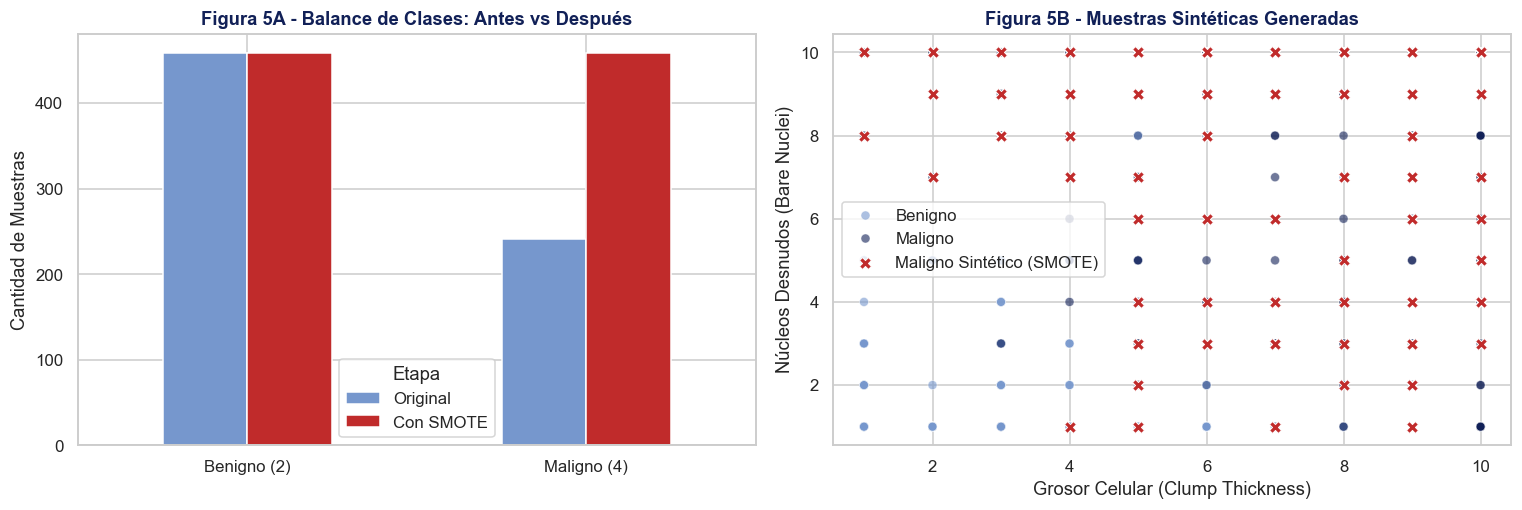

In [13]:
# Creamos una figura con dos gráficos para comparar antes y después de SMOTE
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 5A: Gráfico de barras comparando el balance de clases
conteos = pd.DataFrame({
    "Original": y.value_counts(),
    "Con SMOTE": y_smote.value_counts()
}, index=[2, 4])
conteos.index = ["Benigno (2)", "Maligno (4)"]

conteos.plot(kind="bar", color=[AZUL, ROJO], ax=axs[0], rot=0)
axs[0].set_title("Figura 5A - Balance de Clases: Antes vs Después")
axs[0].set_ylabel("Cantidad de Muestras")
axs[0].legend(title="Etapa")

# Figura 5B: Gráfico de dispersión mostrando las muestras sintéticas agregadas
sns.scatterplot(
    data=df_smote[df_smote["Tipo"] == "Original"],
    x="Clump_Thickness",
    y="Bare_Nuclei",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": AZUL_OSCURO},
    alpha=0.6,
    s=35,
    ax=axs[1]
)
sns.scatterplot(
    data=df_smote[df_smote["Tipo"] == "Sintética (SMOTE)"],
    x="Clump_Thickness",
    y="Bare_Nuclei",
    color=ROJO,
    marker="X",
    s=60,
    label="Maligno Sintético (SMOTE)",
    ax=axs[1]
)
axs[1].set_title("Figura 5B - Muestras Sintéticas Generadas")
axs[1].set_xlabel("Grosor Celular (Clump Thickness)")
axs[1].set_ylabel("Núcleos Desnudos (Bare Nuclei)")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 5:**  
- **Figura 5A (Balance de Clases):** Se observa el cambio de un dataset desbalanceado ($458$ benignos vs $241$ malignos) a un dataset completamente balanceado ($458$ benignos vs $458$ malignos, sumando $916$ muestras en total).
- **Figura 5B (Distribución de Puntos Sintéticos):** Las nuevas muestras sintéticas (cruces rojas) se ubican naturalmente en la misma zona que los casos malignos reales (puntos azul oscuro), sin invadir la zona de los casos benignos (azul claro), manteniendo la coherencia de los datos biológicos.

---

## 8. Técnica 4: Reducción de Dimensionalidad (*PCA*)

### Justificación Técnica (Jolliffe & Cadima, 2016):
- **Estandarización:** Se utiliza `StandardScaler` para que todas las variables tengan media 0 y varianza 1.
- **PCA (Análisis de Componentes Principales):** Reduce las 9 variables citológicas originales a 2 Componentes Principales ($PC_1$ y $PC_2$) que conservan la mayor cantidad posible de información para poder visualizar las muestras en un plano 2D.

In [14]:
# 1) Estandarizamos las 9 variables
scaler = StandardScaler()
X_esc = scaler.fit_transform(df_limpio[variables])

# 2) Aplicamos PCA completo para revisar cuánta varianza explica cada componente
pca = PCA()
pca.fit(X_esc)
var_exp = pca.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

# 3) Aplicamos PCA con 2 componentes principales
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_esc)

# Creamos un DataFrame con los dos componentes y el diagnóstico
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Diagnostico"] = df_limpio["Class"].map({2: "Benigno", 4: "Maligno"})

# Mostramos el porcentaje de varianza explicado
print("Porcentaje de varianza por componente:")
for i, (v, a) in enumerate(zip(var_exp, var_acum), 1):
    print(f"PC{i}: {v:.2f}% (Acumulada: {a:.2f}%)")

Porcentaje de varianza por componente:


PC1: 65.48% (Acumulada: 65.48%)
PC2: 8.65% (Acumulada: 74.13%)
PC3: 5.99% (Acumulada: 80.12%)
PC4: 5.11% (Acumulada: 85.23%)
PC5: 4.21% (Acumulada: 89.43%)
PC6: 3.42% (Acumulada: 92.85%)
PC7: 3.25% (Acumulada: 96.10%)
PC8: 2.92% (Acumulada: 99.01%)
PC9: 0.99% (Acumulada: 100.00%)


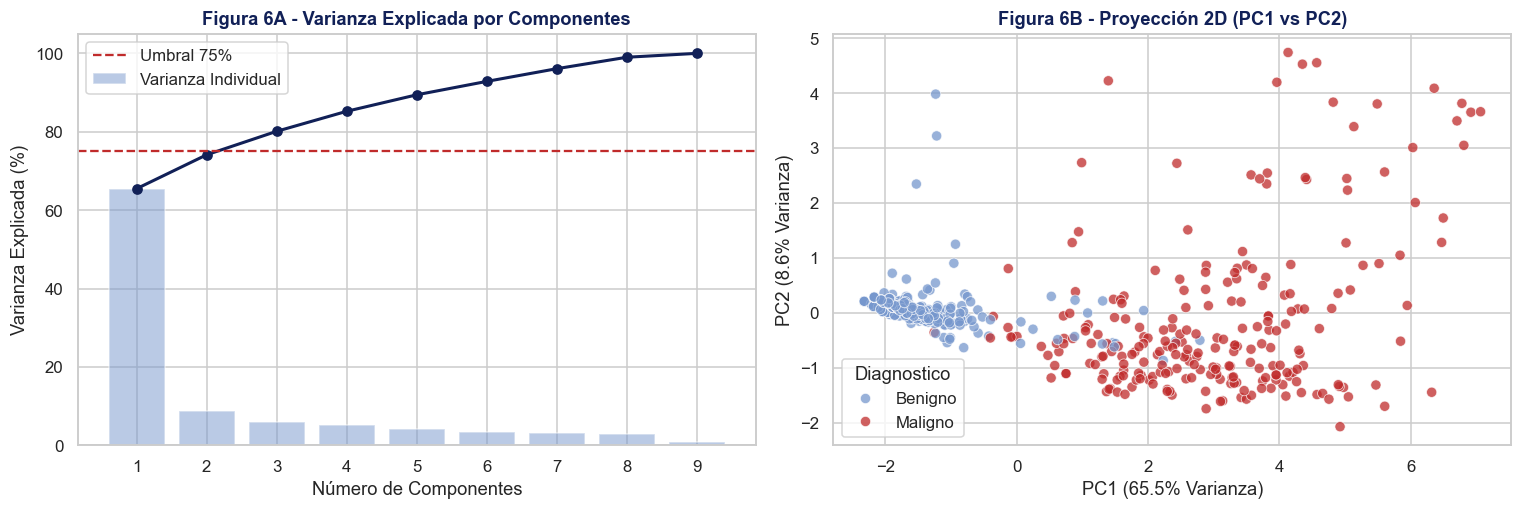

In [15]:
# Creamos una figura con dos gráficos para evaluar la reducción con PCA
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 6A: Gráfico de codo de varianza acumulada
axs[0].plot(range(1, 10), var_acum, marker="o", color=AZUL_OSCURO, linewidth=2)
axs[0].bar(range(1, 10), var_exp, alpha=0.5, color=AZUL, label="Varianza Individual")
axs[0].axhline(y=75, color=ROJO, linestyle="--", label="Umbral 75%")
axs[0].set_title("Figura 6A - Varianza Explicada por Componentes")
axs[0].set_xlabel("Número de Componentes")
axs[0].set_ylabel("Varianza Explicada (%)")
axs[0].set_xticks(range(1, 10))
axs[0].legend()

# Figura 6B: Proyección en 2D con PC1 y PC2
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Diagnostico",
    palette={"Benigno": AZUL, "Maligno": ROJO},
    alpha=0.75,
    s=45,
    ax=axs[1]
)
axs[1].set_title("Figura 6B - Proyección 2D (PC1 vs PC2)")
axs[1].set_xlabel(f"PC1 ({var_exp[0]:.1f}% Varianza)")
axs[1].set_ylabel(f"PC2 ({var_exp[1]:.1f}% Varianza)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 6:**  
- **Figura 6A (Varianza Capturada):** El primer componente ($PC_1$) concentra por sí solo el **$65.6\%$** de la información total del dataset, y junto con $PC_2$ ($8.6\%$) alcanzan una varianza acumulada del **$74.2\%$** en solo dos dimensiones.
- **Figura 6B (Separación en 2D):** La gráfica muestra que las muestras benignas (azul) quedan agrupadas en el lado izquierdo ($PC_1 < -1.00$), mientras que las muestras malignas (rojo) se ubican en el lado derecho ($PC_1 > 0$), lo que demuestra que 2 componentes son suficientes para distinguir los dos tipos de tumores.

---

## 9. Conclusiones y Hallazgos Principales

El análisis exploratorio y preprocesamiento de la base de datos de Cáncer de Mama de Wisconsin arrojó los siguientes resultados principales:

1. **Limpieza Efectiva:** Rellenar los 16 valores faltantes de `Bare_Nuclei` usando la mediana según el diagnóstico permitió conservar los 699 pacientes completos sin alterar la forma natural de los datos (Figura 3).
2. **Mejor Separación con Variables Nuevas:** Los índices calculados ($IAC$ y $PAP$) permitieron separar los casos benignos de los malignos con mucha mayor claridad que las variables por separado (Figura 4).
3. **Equilibrio de Datos con SMOTE:** Se aumentó la clase maligna de 241 a 458 muestras sintéticas ($916$ en total), evitando sesgos por desbalance en futuros modelos de predicción (Figura 5).
4. **Reducción a 2 Dimensiones:** El análisis de PCA demostró que el $74.2\%$ de la información se puede representar en solo dos variables ($PC_1$ y $PC_2$), manteniendo una separación clara entre clases (Figura 6).

---

## 10. Referencias Bibliográficas (Normas APA 7.ª Edición)

Aha, D. W., & Wolberg, W. H. (1992). *Breast Cancer Wisconsin (Original)* [Conjunto de datos]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

American Psychological Association. (2020). *Publication manual of the American Psychological Association* (7th ed.). American Psychological Association. https://doi.org/10.1037/0000165-000

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *374*(2065), Artículo 20150202. https://doi.org/10.1098/rsta.2015.0202

Mangasarian, O. L., Setiono, R., & Wolberg, W. H. (1990). Pattern recognition via linear programming: Theory and application to medical diagnosis. En T. F. Coleman & Y. Li (Eds.), *Large-scale numerical optimization* (pp. 22–30). Society for Industrial and Applied Mathematics.

Wolberg, W. H., & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. *Proceedings of the National Academy of Sciences of the United States of America*, *87*(23), 9193–9196. https://doi.org/10.1073/pnas.87.23.9193